# Detecção de movimentações anormais no mercado da DeepSeek

**Entrega de Banco de Dados II - Rebecca Gomes Simão**

## Contexto

O Polymarket permite que usuários negociem previsões sobre acontecimentos futuros. O trabalho analisa o mercado **“DeepSeek banned in US before April?”**, identificado pelo `market_id 519801`.

O mercado discutia se a DeepSeek seria banida nos Estados Unidos antes de abril de 2025. E foi escolhida como pergunta:

Quais dias apresentaram atividade anormal nesse mercado e em que medida diferentes regras de alerta conseguem identificar esses períodos?

Tendo como hipótese: **Dias com volume ou quantidade de negociações muito acima do comportamento recente podem estar relacionados a acontecimentos relevantes para o mercado.**

Os dados permitem identificar coincidências temporais, mas não são suficientes para afirmar que uma notícia causou diretamente uma movimentação.

## Objetivo

Analisar o comportamento diário do mercado e construir dois alertas em SQL:

1. um alerta baseado no volume negociado e na quantidade de negociações;
2. um alerta baseado em mudanças bruscas na probabilidade implícita do resultado YES.

O objetivo não é prever o resultado do mercado, mas selecionar dias que merecem uma investigação mais detalhada.


## Estrutura da análise

A análise foi organizada nas seguintes etapas:

1. busca e escolha do mercado;
2. avaliação do histórico disponível;
3. exploração do comportamento diário;
4. construção dos dois alertas;
5. comparação dos resultados;
6. discussão das conclusões e limitações.

In [ ]:
# preparacao p leiutra posterior de arquivos
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PASTA_DADOS = Path("dados")

PASTA_DADOS.mkdir(exist_ok=True)


def carrega_csv(nome_arquivo):
    caminho = PASTA_DADOS / nome_arquivo
    df = pd.read_csv(caminho)

    for coluna in df.columns:
        if "date" in coluna.lower():df[coluna] = pd.to_datetime(df[coluna], errors="coerce")

    return df


## Etapa 1: Busca e escolha do mercado


Foi buscado todos os mercados que continham DeepSeek no título, organizando os 56 encontrados por volume. O mercado escolhido ficou em quarto lugar, mas foi selecionado porque tratava de um acontecimento específico, tinha prazo definido e possuía 69 dias de histórico.

Foi utilizada a view `v_top_markets` nesta etapa por já apresentar dados agregados. Assim, não foi necessário consultar a tabela detalhada de negociações, que possui maior custo de processamento.


### Resultado

Para o trabalho, foi escolhido o mercado **“DeepSeek banned in US before April?”**, identificado pelo `market_id 519801`.

Embora não fosse o primeiro da lista, ele ocupava a quarta posição em volume e apresentava características adequadas para a análise:

- pergunta relacionada a um acontecimento específico;
- prazo de encerramento definido;
- 69 dias de atividade;
- 2.845 negociações;
- aproximadamente US$ 255 mil negociados.

Esses dados indicam que o mercado possui histórico suficiente para uma análise diária.




```sql
-- Q1: busca inicial dos mercados relacionados à DeepSeek. (293,32 MB)


SELECT
  market_id,
  event_title,
  first_trade_date,
  last_trade_date,
  active_days,
  total_trades,
  total_usd_volume,
  lifetime_avg_price
FROM `even-continuity-441808-j0.polymarket_mart.v_top_markets`
WHERE LOWER(event_title) LIKE '%deepseek%'
ORDER BY total_usd_volume DESC;
```



In [34]:
q1 = carrega_csv("q1.csv")
q1.head(10)

,market_id,event_title,first_trade_date,last_trade_date,active_days,total_trades,total_usd_volume,lifetime_avg_price
0,1360940,DeepSeek V4 released by...?,2026-02-11,2026-03-16,34,8177,357344,0.4789
1,1797301,DeepSeek V4 released by...?,2026-03-31,2026-04-24,25,5869,271533,0.4983
2,1170467,DeepSeek V4 released by...?,2026-01-13,2026-04-01,79,7510,263252,0.4436
3,519801,DeepSeek banned in US before April?,2025-01-23,2025-04-01,69,2845,255077,0.5247
4,2060041,DeepSeek V4 released by...?,2026-04-23,2026-04-24,2,3020,232294,0.4831
5,520537,DeepSeek confirmed to have used banned Nvidia ...,2025-01-27,2025-03-01,34,2559,147428,0.5552
6,1570752,DeepSeek V4 released by...?,2026-03-12,2026-04-16,36,4808,124595,0.4715
7,537918,DeepSeek V4 released before July?,2025-04-18,2025-07-01,74,862,90460,0.4806
8,1333269,DeepSeek V4 released by...?,2026-02-05,2026-03-01,25,2888,86417,0.5024
9,520266,DeepSeek R2 released before May?,2025-01-27,2025-05-01,93,2149,84810,0.4665


## Etapa 2: Avaliação do histórico disponível

O próximo passo foi validar se havia histórico o suficiente.

Entre 23 de janeiro e 1º de abril de 2025, foram registrados:

- 69 dias ativos;
- 2.845 negociações;
- US$ 255.077 em volume;

- média de 41,23 negociações por dia;
- média de US$ 3.696,77 negociados por dia.

O número de dias ativos corresponde a todo o intervalo entre a primeira e a última negociação. Isso indica que houve atividade diariamente e permite realizar a análise no grão diário.

As médias, porém, não mostram como a atividade foi distribuída. Alguns dias muito movimentados podem elevar os valores médios. Por isso, a próxima etapa analisa cada dia separadamente.

```sql

-- Q2: resumo do histórico disponível (264,73 MB)

SELECT
  market_id,
  event_title,
  first_trade_date,
  last_trade_date,
  active_days,
  total_trades,
  total_usd_volume,
  ROUND(SAFE_DIVIDE(total_trades, active_days),2) AS media_negociacoes_por_dia,
  ROUND(SAFE_DIVIDE(total_usd_volume, active_days),2) AS media_volume_por_dia
FROM `even-continuity-441808-j0.polymarket_mart.v_top_markets`
WHERE market_id = '519801';

```

In [35]:
q2 = carrega_csv("q2.csv")

q2.head()

,market_id,event_title,first_trade_date,last_trade_date,active_days,total_trades,total_usd_volume,media_negociacoes_por_dia,media_volume_por_dia
0,519801,DeepSeek banned in US before April?,2025-01-23,2025-04-01,69,2845,255077,41.23,3696.77


## Etapa 3: Exploração do comportamento diário

Foram observados o número de negociações, o volume, o preço médio e a diferença entre os menores e maiores preços registrados a cada dia. Também foi utilizada a média móvel de sete dias do volume, que permite comparar cada dia com o comportamento recente do mercado.

```sql
-- Q3: comportamento diário do mercado escolhido (350,49 MB)

SELECT
  market_id,
  event_title,
  trade_date,
  daily_trade_count,

  ROUND(daily_usd_volume,2) AS volume_usd,
  ROUND(avg_trade_price,4) AS preco_medio,
  ROUND(min_trade_price,4) AS preco_min,
  ROUND(max_trade_price,4) AS preco_max,
  ROUND(max_trade_price-min_trade_price,4) AS amplitude_dia,
  ROUND(rolling_7d_avg_volume,2) AS media_movel_volume_7d

FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = '519801'
ORDER BY trade_date;
```

In [36]:
q3 = carrega_csv("q3.csv")

#print(f"Quantidade de dias: {len(q3)}")
print("Período:",q3["trade_date"].min(),"até",q3["trade_date"].max())

q3.head()

Período: 2025-01-23 00:00:00 até 2025-04-01 00:00:00


,market_id,event_title,trade_date,daily_trade_count,volume_usd,preco_medio,preco_min,preco_max,amplitude_dia,media_movel_volume_7d
0,519801,DeepSeek banned in US before April?,2025-01-23,19,483.53,0.3011,0.08,0.89,0.81,483.53
1,519801,DeepSeek banned in US before April?,2025-01-24,25,231.37,0.2840,0.07,0.93,0.86,357.45
2,519801,DeepSeek banned in US before April?,2025-01-25,19,831.43,0.3837,0.06,0.94,0.88,515.44
3,519801,DeepSeek banned in US before April?,2025-01-26,36,3126.94,0.6211,0.04,0.95,0.91,1168.32
4,519801,DeepSeek banned in US before April?,2025-01-27,238,12796.62,0.5106,0.02,0.96,0.94,3493.98


In [37]:
q3.describe().round(2)

,market_id,trade_date,daily_trade_count,volume_usd,preco_medio,preco_min,preco_max,amplitude_dia,media_movel_volume_7d
count,69.0,69,69.00,69.00,69.00,69.00,69.00,69.00,69.00
mean,519801.0,2025-02-26 00:00:00,41.23,3696.78,0.52,0.03,0.94,0.90,3377.45
min,519801.0,2025-01-23 00:00:00,2.00,0.84,0.02,0.00,0.02,0.00,148.46
25%,519801.0,2025-02-09 00:00:00,12.00,231.37,0.36,0.01,0.95,0.90,693.76
50%,519801.0,2025-02-26 00:00:00,27.00,1109.47,0.51,0.02,0.98,0.95,1397.23
75%,519801.0,2025-03-15 00:00:00,39.00,3126.94,0.66,0.05,0.99,0.98,5365.04
max,519801.0,2025-04-01 00:00:00,315.00,69427.29,0.91,0.13,1.00,1.00,11467.05
std,0.0,NaN,57.85,9074.90,0.21,0.03,0.16,0.17,3727.61


## Dicionário para entendimento:

- trade_date: dia analisado;
- daily_trade_count: quantidade de negociações;
- volume_usd: valor negociado no dia;
- preco_medio: média dos preços registrados;
- amplitude_dia: diferença entre o maior e o menor preço;
- media_movel_volume_7d: referência baseada nos sete dias recentes.

### Definição das variáveis do primeiro alerta

Para identificar dias realmente atípicos, foram combinadas duas informações:

- o volume do dia em relação à média móvel de sete dias;
- a quantidade de negociações realizadas no dia.

O uso conjunto evita que uma única negociação de valor muito alto seja interpretada automaticamente como uma movimentação geral do mercado.

## Análise por gráfico

Foi criado um gráfico para auxiliar na visualização e percepção de padrões. Cada ponto representa um dia.
- Mais à direita: volume mais alto em relação ao comportamento recente.
- Mais acima: maior quantidade de negociações.
- Linha vertical: volume pelo menos duas vezes maior que a média móvel.
- Linha horizontal: dias pertencentes aos 25% com mais negociações.


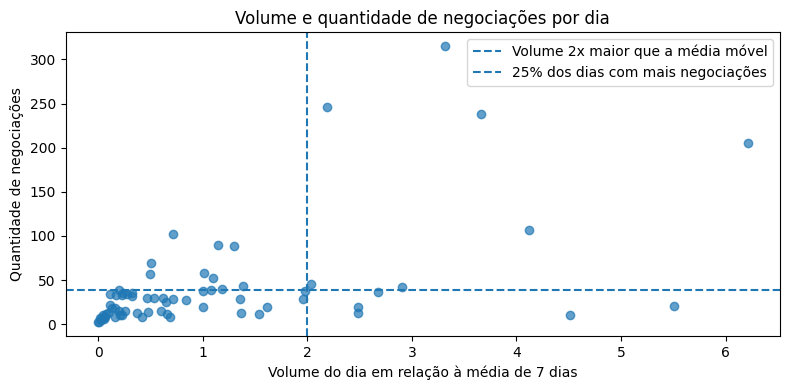

In [38]:
q3["razao_volume_7d"] = (q3["volume_usd"] / q3["media_movel_volume_7d"])

limite_negociacoes = q3["daily_trade_count"].quantile(0.75)

plt.figure(figsize=(8, 4))

plt.scatter(q3["razao_volume_7d"],q3["daily_trade_count"],alpha=0.7)

plt.axvline(2,linestyle="--",label="Volume 2x maior que a média móvel")

plt.axhline(limite_negociacoes,linestyle="--",label="25% dos dias com mais negociações")

plt.xlabel("Volume do dia em relação à média de 7 dias")
plt.ylabel("Quantidade de negociações")
plt.title("Volume e quantidade de negociações por dia")
plt.legend()

plt.tight_layout()
plt.show()

## Etapa 4: Construção dos alertas

### Alerta 1: aumento de volume e negociações

O primeiro alerta identifica dias em que houve um aumento no volume e na quantidade de negociações.

Foram definidas duas condições:

- volume pelo menos duas vezes maior que a média dos sete dias anteriores;
- quantidade de negociações entre os 25% maiores valores do período.

A média considera apenas os dias anteriores, sem incluir o próprio dia analisado. Assim, um volume muito alto não aumenta a referência usada para avaliá-lo.

O alerta é disparado somente quando as duas condições são atendidas.


```sql
-- ALERTA 1: identifica aumento de volume e negociações. (264,73 MB)
WITH dados AS (
  SELECT market_id, event_title, trade_date, daily_trade_count, daily_usd_volume
  FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
  WHERE market_id = '519801'
),
serie AS (
  SELECT market_id, event_title, trade_date, daily_trade_count, daily_usd_volume,
    AVG(daily_usd_volume) OVER (
      ORDER BY trade_date ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS media_volume_7d_anterior
  FROM dados
),
limite AS (
  SELECT APPROX_QUANTILES(daily_trade_count, 4)[OFFSET(3)] AS terceiro_quartil_negociacoes
  FROM dados
)
SELECT
  market_id, event_title, trade_date, daily_trade_count,
  ROUND(daily_usd_volume, 2) AS volume_usd,
  ROUND(media_volume_7d_anterior, 2) AS media_volume_7d_anterior,
  terceiro_quartil_negociacoes,
  ROUND(SAFE_DIVIDE(daily_usd_volume, media_volume_7d_anterior), 2) AS razao_volume_7d,
  'volume e negociações acima do comportamento recente' AS tipo_alerta
FROM serie
CROSS JOIN limite
WHERE media_volume_7d_anterior IS NOT NULL
  AND daily_usd_volume >= 2 * media_volume_7d_anterior
  AND daily_trade_count >= terceiro_quartil_negociacoes
ORDER BY trade_date;```

In [39]:
alerta_1 = carrega_csv("alerta1.csv")

print(f"Quantidade de alertas: {len(alerta_1)}")

alerta_1

Quantidade de alertas: 7


,market_id,event_title,trade_date,daily_trade_count,volume_usd,media_volume_7d_anterior,terceiro_quartil_negociacoes,razao_volume_7d,tipo_alerta
0,519801,DeepSeek banned in US before April?,2025-01-27,238,12796.62,1168.32,39,10.95,volume e negociações acima do comportamento re...
1,519801,DeepSeek banned in US before April?,2025-01-28,315,21535.65,3493.98,39,6.16,volume e negociações acima do comportamento re...
2,519801,DeepSeek banned in US before April?,2025-01-29,246,17692.51,6500.92,39,2.72,volume e negociações acima do comportamento re...
3,519801,DeepSeek banned in US before April?,2025-03-07,107,8339.63,882.53,39,9.45,volume e negociações acima do comportamento re...
4,519801,DeepSeek banned in US before April?,2025-03-18,42,1379.74,283.94,39,4.86,volume e negociações acima do comportamento re...
5,519801,DeepSeek banned in US before April?,2025-03-19,45,1181.93,474.22,39,2.49,volume e negociações acima do comportamento re...
6,519801,DeepSeek banned in US before April?,2025-03-28,205,69427.29,1270.59,39,54.64,volume e negociações acima do comportamento re...


## Análise de resultado:

Os dias encontrados foram:
- 27, 28 e 29 de janeiro;
- 7, 18, 19 e 28 de março.

Nesses períodos, o volume teve um grande aumento comparado aos seus 7 dias anteriores (pelo menos duas vezes maior que a média móvel de sete dias) e a quantidade de negociações estava entre os 25%  maiores valores do período analisado.

Exemplo dia dia 27 de janeiro:

- volume do dia: US$ 12.796,62;

- média dos sete dias anteriores disponíveis: US$ 1.168,32;
- razão entre os volumes: 10,95 vezes;
- quantidade de negociações: 238.

## Eventos externos:
Em seguida, esses períodos foram comparados com notícias relacionadas à DeepSeek e a possíveis restrições nos Estados Unidos, sendo:
- **27 a 29 de Janeiro:** Nesse período o deepseek teve forte repercusão nos estados unidos, sendo dia 28, o dia em que a Casa Branca informou que avaliava
as implicações do aplicativo para a segurança nacional.
- **7 de março:** foi noticiado que o governo norte-americano avaliava proibir a DeepSeek em dispositivos governamentais, além de discutir possíveis restrições em lojas de aplicativos e serviços de nuvem.
- **18 e 19 de março:** foi divulgada a proibição da DeepSeek em equipamentos de setores do Departamento de Comércio dos Estados Unidos.
- **28 de março:** não encontrei um acontecimento externo claramente associado. Uma hipótese é que o aumento da atividade estivesse relacionado à proximidade do encerramento do mercado, em 1º de abril.

Dos quatro períodos identificados, três coincidiram com acontecimentos externos relacionados à DeepSeek. A taxa de correspondência temporal do Alerta 1 foi de 75%.

### Alerta 2: mudança brusca na expectativa do mercado

O segundo alerta busca mudanças relevantes na probabilidade implícita do resultado YES.

## Probabilidade implícita
No Polymarket, o preço do resultado YES pode ser interpretado como uma probabilidade aproximada:

preço 0,70: mercado indica aproximadamente 70% para YES;
preço 0,30: mercado indica aproximadamente 30% para YES e, portanto, 70% para NO.

## Objetivo:
Diferentemente do primeiro alerta, que identifica aumento de atividade, este analisa a direção da expectativa do mercado.

Como a base possui negociações dos resultados YES e NO, os preços foram primeiro convertidos para a perspectiva do YES. Depois, foi calculado o preço médio diário ponderado pelo volume negociado.

```sql
-- ALERTA 2: identifica mudanças bruscas na probabilidade implícita do YES (359,24 MB)
WITH trades_normalizados AS (
  SELECT DATE(trade_timestamp) AS trade_date,
    SAFE_CAST(usd_amount AS FLOAT64) AS usd_amount,
    CASE
      WHEN nonusdc_side = 'token1' THEN SAFE_CAST(price AS FLOAT64)
      WHEN nonusdc_side = 'token2' THEN 1 - SAFE_CAST(price AS FLOAT64)
    END AS preco_yes
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '519801'
    AND DATE(trade_timestamp) BETWEEN DATE '2025-01-23' AND DATE '2025-04-01'
    AND nonusdc_side IN ('token1', 'token2')
    AND SAFE_CAST(usd_amount AS FLOAT64) > 0
    AND SAFE_CAST(price AS FLOAT64) BETWEEN 0 AND 1
),
serie_diaria AS (
  SELECT trade_date, COUNT(*) AS quantidade_negociacoes,
    SUM(usd_amount) AS volume_usd,
    SAFE_DIVIDE(SUM(preco_yes * usd_amount), SUM(usd_amount)) AS preco_yes_atual
  FROM trades_normalizados
  WHERE preco_yes IS NOT NULL
  GROUP BY trade_date
),
comparacao AS (
  SELECT trade_date, quantidade_negociacoes, volume_usd, preco_yes_atual,
    LAG(preco_yes_atual) OVER (ORDER BY trade_date) AS preco_yes_anterior
  FROM serie_diaria
)
SELECT
  trade_date, quantidade_negociacoes,
  ROUND(volume_usd, 2) AS volume_usd,
  ROUND(preco_yes_anterior, 4) AS preco_yes_anterior,
  ROUND(preco_yes_atual, 4) AS preco_yes_atual,
  ROUND(100 * (preco_yes_atual - preco_yes_anterior), 2) AS variacao_pontos_percentuais,
  CASE
    WHEN preco_yes_atual > preco_yes_anterior THEN 'ALTA_BRUSCA_DO_SIM'
    ELSE 'QUEDA_BRUSCA_DO_SIM'
  END AS tipo_alerta
FROM comparacao
WHERE preco_yes_anterior IS NOT NULL
  AND ABS(preco_yes_atual - preco_yes_anterior) >= 0.03
  AND quantidade_negociacoes >= 30
ORDER BY trade_date;
```

In [40]:
alerta_2 = carrega_csv("alerta2.csv")

alerta_2.head(10)

,trade_date,quantidade_negociacoes,volume_usd,preco_yes_anterior,preco_yes_atual,variacao_pontos_percentuais,tipo_alerta
0,2025-01-27,238,12796.62,0.0632,0.1622,9.90,ALTA_BRUSCA_DO_SIM
1,2025-01-28,315,21535.65,0.1622,0.1249,-3.73,QUEDA_BRUSCA_DO_SIM
2,2025-01-29,246,17692.51,0.1249,0.1623,3.74,ALTA_BRUSCA_DO_SIM
3,2025-02-10,90,6712.33,0.0748,0.1068,3.20,ALTA_BRUSCA_DO_SIM
4,2025-02-12,33,1135.34,0.0982,0.0569,-4.13,QUEDA_BRUSCA_DO_SIM
5,2025-03-08,52,2643.49,0.0503,0.0143,-3.60,QUEDA_BRUSCA_DO_SIM


### Regras utilizadas

A exploração não identificou uma mudança direta entre YES e NO como resultado mais provável. Mesmo nos maiores movimentos, a probabilidade do YES permaneceu baixa.

Por isso, o segundo alerta foi definido para identificar aumentos ou quedas bruscas na probabilidade implícita do YES.

Foram utilizadas duas condições:

- variação de pelo menos 3 pontos percentuais, para cima ou para baixo;
- pelo menos 30 negociações no dia.

A quantidade mínima de negociações reduz a influência de mudanças provocadas por poucas operações.

### Resultado do Alerta 2

O segundo alerta identificou seis dias:

- 27, 28 e 29 de janeiro;
- 10 e 12 de fevereiro;
- 8 de março.

O maior movimento ocorreu em 27 de janeiro, quando a probabilidade implícita do YES passou de 6,32% para 16,22%, uma alta de 9,90 pontos percentuais.

O alerta representa uma mudança brusca na expectativa do mercado. Ainda assim,Em nenhum dos dias analisados, o preço médio diário ponderado do YES superou 50%.

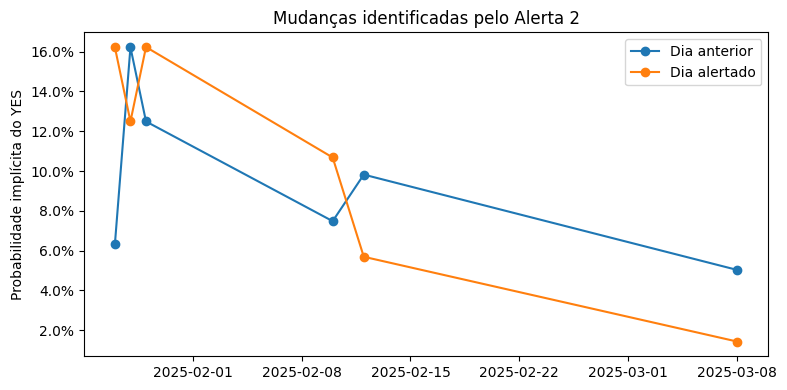

In [41]:
# Visualização do Alerta 2

alerta_2 = alerta_2.sort_values("trade_date")

plt.figure(figsize=(8, 4))
plt.plot(alerta_2["trade_date"], alerta_2["preco_yes_anterior"], marker="o", label="Dia anterior")
plt.plot(alerta_2["trade_date"], alerta_2["preco_yes_atual"], marker="o", label="Dia alertado")
plt.ylabel("Probabilidade implícita do YES")
plt.title("Mudanças identificadas pelo Alerta 2")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.legend()
plt.tight_layout()
plt.show()

## Etapa 5: Comparação dos resultados

Três dos seis dias identificados pelo Alerta 2 também apareceram no Alerta 1. Portanto, 50% das mudanças bruscas na probabilidade ocorreram em dias com atividade elevada.

Isso mostra que algumas mudanças na expectativa vieram acompanhadas de maior movimentação, enquanto outras ocorreram sem um aumento anormal de volume.

In [42]:
datas_alerta_1 = set(alerta_1["trade_date"])
datas_alerta_2 = set(alerta_2["trade_date"])

dias_em_comum = datas_alerta_1.intersection(datas_alerta_2)

print(f"Dias em comum: {len(dias_em_comum)}")


Dias em comum: 3


## Etapa 6: Conclusões e limitações

Os dois alertas observaram aspectos diferentes do mercado. O primeiro identificou aumento de atividade, enquanto o segundo destacou mudanças rápidas na probabilidade implícita do YES.

Os resultados mostram coincidências temporais, mas não comprovam que as notícias causaram as movimentações.

## Métricas encontradas
Alerta 1: 75% de correspondência temporal;

Alerta 2: 50% de coincidência com atividade elevada.

### Limitações

- os limites escolhidos podem precisar de ajustes em outros mercados;
- a análise diária pode esconder mudanças ocorridas dentro do mesmo dia;
